<a href="https://colab.research.google.com/github/mohamadfaisalbashir/Introduction-to-Machine-Learning-with-Python/blob/main/06_algorithm_chains_and_pipelines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Algorithm chains and pipelines**
This notebook covers algorithm chains and pipelines:

1. Parameter Selection with Preprocessing
2. Building Pipelines
3. Using Pipelines in Grid Searches (and Preventing Information Leakage)
4. The General Pipeline Interface and make_pipeline
5. Accessing Step Attributes
6. Grid-Searching Preprocessing Steps, Model Parameters, and Which Model to Use
7. Summary

# **Setup**

In [ ]:
!pip install -q mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 13.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mglearn
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Patch mglearn.tools.heatmap for numpy/matplotlib compatibility
import mglearn.tools as _mt
def _patched_heatmap(values, xlabel, ylabel, xticklabels, yticklabels,
                     cmap=None, vmin=None, vmax=None, ax=None, fmt="%0.2f"):
    if ax is None:
        ax = plt.gca()
    values = np.array(values, dtype=np.float64)
    img = ax.pcolor(values, cmap=cmap, vmin=vmin, vmax=vmax)
    img.update_scalarmappable()
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xticks(np.arange(len(xticklabels)) + .5)
    ax.set_yticks(np.arange(len(yticklabels)) + .5)
    ax.set_xticklabels(xticklabels)
    ax.set_yticklabels(yticklabels)
    ax.set_aspect(1)
    for p, color, value in zip(img.get_paths(), img.get_facecolors(),
                               values.ravel()):
        x, y = p.vertices[:-2, :].mean(0)
        c = 'k' if np.mean(color[:3]) > 0.5 else 'w'
        ax.text(x, y, fmt % float(value), color=c, ha="center", va="center")
    return img
_mt.heatmap = _patched_heatmap

# **Introduction**

As established in our previous discussions on data representation, the efficacy of most machine learning models depends heavily on how the data is prepared, ranging from manual feature scaling to advanced unsupervised learning techniques. This necessitates a cohesive workflow where multiple processing stages and models are integrated rather than treated as isolated steps. In this section, we will utilize the Pipeline class to streamline these complex sequences, specifically demonstrating how it can be paired with GridSearchCV to optimize parameters across the entire transformation chain simultaneously. To illustrate this synergy, we will re-examine the cancer dataset—where we previously observed significant performance gains in a kernel SVM through MinMaxScaler—by implementing a consolidated code structure that handles everything from data splitting to final model training.

In [ ]:
from sklearn.svm import SVC
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# load and split the data
cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, random_state=0)

# compute minimum and maximum on the training data
scaler = MinMaxScaler().fit(X_train)

In [ ]:
# rescale the training data
X_train_scaled = scaler.transform(X_train)

svm = SVC()
# learn an SVM on the scaled training data
svm.fit(X_train_scaled, y_train)

# scale the test data and score the scaled data
X_test_scaled = scaler.transform(X_test)
print("Test score: {:.2f}".format(svm.score(X_test_scaled, y_test)))

Test score: 0.97


The SVM's 97% accuracy on the scaled cancer dataset underscores the critical necessity of preprocessing for kernel-based models; without proper scaling, features with larger magnitudes, such as mean area, would disproportionately dominate the RBF kernel’s distance calculation—$\|\mathbf{x} - \mathbf{x}'\|^2$—effectively marginalizing features with smaller ranges. By utilizing MinMaxScaler to normalize the feature space, we ensure a level playing field where each attribute contributes equally to the model's decision boundaries. Crucially, to maintain the integrity of our evaluation and prevent information leakage, the scaler must be fitted exclusively on the training set—learning the parameters $\min(\mathbf{x}_j^{\text{train}})$ and $\max(\mathbf{x}_j^{\text{train}})$—before being applied to the test data, thereby ensuring that the model remains entirely 'blind' to the distribution of the unseen data during the training phase.

## **1. Parameter Selection with Preprocessing**

Now let’s say we want to find better parameters for SVC using GridSearchCV. How should we go about doing this? A naive approach might look like this:

In [ ]:
from sklearn.model_selection import GridSearchCV
# for illustration purposes only, don't use this code!
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100],
              'gamma': [0.001, 0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(SVC(), param_grid=param_grid, cv=5)
grid.fit(X_train_scaled, y_train)
print("Best cross-validation accuracy: {:.2f}".format(grid.best_score_))
print("Best set score: {:.2f}".format(grid.score(X_test_scaled, y_test)))
print("Best parameters: ", grid.best_params_)

Best cross-validation accuracy: 0.98
Best set score: 0.97
Best parameters:  {'C': 1, 'gamma': 1}


In this approach, we performed a grid search on the SVC parameters using the scaled dataset; however, this introduces a critical methodological nuance known as data leakage. By scaling the entire training set before applying cross-validation, information from the validation folds—which are supposed to act as 'unseen' data—has already influenced the scaling parameters (like the mean and variance). This inadvertently informs the model about the distribution of the test parts within each split, failing to accurately simulate how the model would encounter genuinely new data that might possess entirely different ranges. Consequently, as illustrated in Figure 6-1, this practice creates a discrepancy between the cross-validation process and the final evaluation, where the test set remains strictly independent of the training transformations.

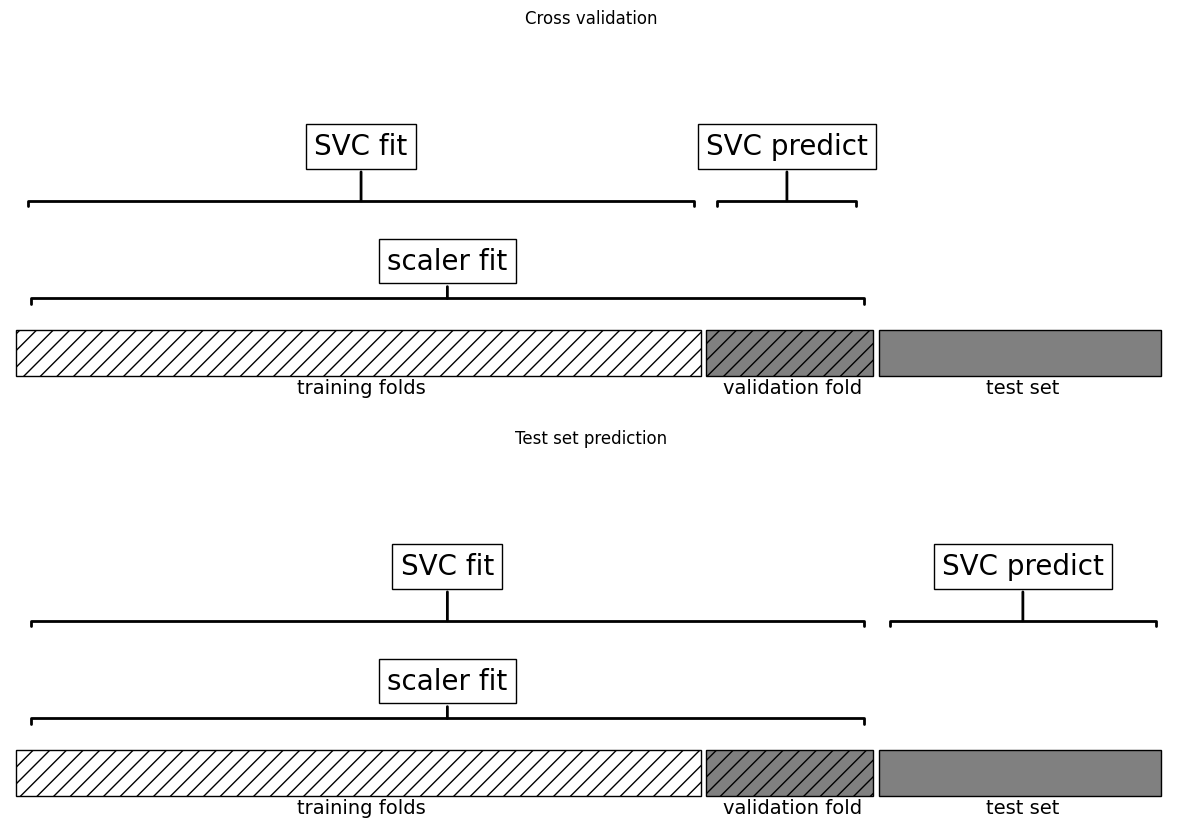

In [ ]:
mglearn.plots.plot_improper_processing()

When data leakage occurs, the cross-validation splits fail to accurately represent the model's performance on unseen data, often leading to misleadingly optimistic results and the selection of suboptimal parameters. To mitigate this, it is crucial that the dataset is split before any preprocessing—ensuring that any knowledge extraction remains strictly confined to the training set by treating cross-validation as the 'outermost loop' of the workflow. In practice, we can implement this robustly using scikit-learn’s Pipeline class, which allows us to encapsulate multiple processing steps—such as data scaling and supervised learning—into a single estimator. By leveraging a Pipeline within cross_val_score or GridSearchCV, we ensure that the entire modeling process adheres to strict validation principles, maintaining the integrity of our results and the reliability of the final model.

## **2. Building Pipelines**

To streamline the workflow, we can utilize the Pipeline class to integrate the data scaling process via MinMaxScaler with the subsequent SVM model training. The initial step involves constructing a pipeline object by defining a sequential list of operations, where each element is represented as a tuple consisting of a user-defined identifier and its corresponding estimator instance. This approach not only ensures that the preprocessing and modeling phases are tightly coupled but also maintains a clean and reproducible structure for our experimental setup.

In [ ]:
from sklearn.pipeline import Pipeline
pipe = Pipeline([("scaler", MinMaxScaler()), ("svm", SVC())])

Here, we created two steps: the first, called "scaler", is an instance of MinMaxScaler, and the second, called "svm", is an instance of SVC. Now, we can fit the pipeline, like any other scikit-learn estimator

In [ ]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', MinMaxScaler()), ('svm', SVC())])

Here, pipe.fit first calls fit on the first step (the scaler), then transforms the training data using the scaler, and finally fits the SVM with the scaled data. To evaluate on the test data, we simply call pipe.score:

In [ ]:
print("Test score: {:.2f}".format(pipe.score(X_test, y_test)))

Test score: 0.97


By invoking the score method directly on the pipeline, the test data undergoes an automated transformation through the scaler before being evaluated by the SVM. Notably, this approach yields results identical to our manual transformation process, yet it significantly streamlines the 'preprocessing and classification' workflow. Beyond just reducing code complexity, the primary advantage of this integration lies in its versatility, as it allows us to utilize the pipeline as a single, cohesive estimator within more advanced validation frameworks like cross_val_score or GridSearchCV.

## **3. Using Pipelines in Grid Searches**

Integrating a pipeline into a grid search follows the standard estimator workflow, where we define a parameter grid and pass it into a GridSearchCV object alongside the pipeline itself. The primary distinction lies in the syntax of the parameter grid; because a pipeline consists of multiple stages, we must explicitly map each hyperparameter to its corresponding step using a double underscore (__) notation. For instance, since both C and gamma belong to the SVC component—which we have labeled as 'svm'—the keys in our grid dictionary must be specified as svm__C and svm__C, ensuring the grid search correctly identifies which part of the architectural sequence to tune.

In [ ]:
param_grid = {'svm__C': [0.001, 0.01, 0.1, 1, 10, 100],
              'svm__gamma': [0.001, 0.01, 0.1, 1, 10, 100]}

With this parameter grid we can use GridSearchCV as usual:

In [ ]:
grid = GridSearchCV(pipe, param_grid=param_grid, cv=5)
grid.fit(X_train, y_train)
print("Best cross-validation accuracy: {:.2f}".format(grid.best_score_))
print("Test set score: {:.2f}".format(grid.score(X_test, y_test)))
print("Best parameters: {}".format(grid.best_params_))

Best cross-validation accuracy: 0.98
Test set score: 0.97
Best parameters: {'svm__C': 1, 'svm__gamma': 1}


In contrast to the grid search we did before, now for each split in the cross-validation, the MinMaxScaler is refit with only the training splits and no information is leaked from the test split into the parameter search. Compare this (following figure) with the improper processing figure above:

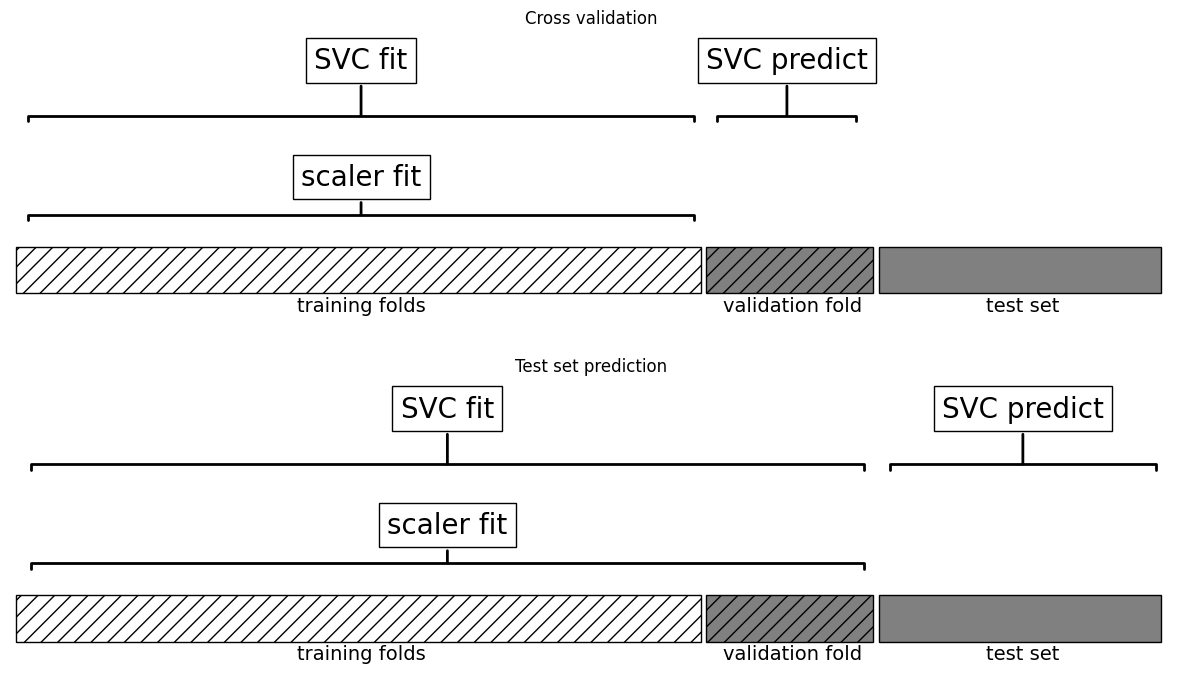

In [ ]:
mglearn.plots.plot_proper_processing()

The impact of leaking information in the cross-validation varies depending on the nature of the preprocessing step. Estimating the scale of the data using the test fold usually doesn’t have a terrible impact, while using the test fold in feature extraction and feature selection can lead to substantial differences in outcomes.

### **3.1. Illustrating Information Leakage**

A great example of leaking information in cross-validation is given in Hastie, Tibshirani, and Friedman's book The Elements of Statistical Learning. Let's consider a synthetic regression task with 100 samples and 10,000 features that are sampled independently from a Gaussian distribution. We also sample the response from a Gaussian distribution:

In [ ]:
rnd = np.random.RandomState(seed=0)
X = rnd.normal(size=(100, 10000))
y = rnd.normal(size=(100,))

Given the way we created the dataset, there is no relation between the data, X, and the target, y (they are independent), so it should not be possible to learn anything from this dataset. We will now do the following. First, select the most informative of the 10 features using SelectPercentile feature selection, and then we evaluate a Ridge regressor using cross-validation:

In [ ]:
from sklearn.feature_selection import SelectPercentile, f_regression

select = SelectPercentile(score_func=f_regression, percentile=5).fit(X, y)
X_selected = select.transform(X)
print("X_selected.shape: {}".format(X_selected.shape))

X_selected.shape: (100, 500)


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge

print("Cross-validation accuracy (cv only on ridge): {:.2f}".format(
    np.mean(cross_val_score(Ridge(), X_selected, y, cv=5))))

Cross-validation accuracy (cv only on ridge): 0.91


The mean R2 computed by cross-validation is 0.91, indicating a very good model.
This clearly cannot be right, as our data is entirely random. What happened here is that our feature selection picked out some features among the 10,000 random features that are (by chance) very well correlated with the target. Because we fit the feature selection outside of the cross-validation, it could find features that are correlated both on the training and the test folds. The information we leaked from the test folds was very informative, leading to highly unrealistic results. Let’s compare this to a proper cross-validation using a pipeline:

In [ ]:
pipe = Pipeline([("select", SelectPercentile(score_func=f_regression,
                                              percentile=5)),
                 ("ridge", Ridge())])
print("Cross-validation accuracy (pipeline): {:.2f}".format(
    np.mean(cross_val_score(pipe, X, y, cv=5))))

Cross-validation accuracy (pipeline): -0.25


This time, we get a negative R2 score, indicating a very poor model. Using the pipe line, the feature selection is now inside the cross-validation loop. This means features can only be selected using the training folds of the data, not the test fold. The feature selection finds features that are correlated with the target on the training set, but because the data is entirely random, these features are not correlated with the target on the test set. In this example, rectifying the data leakage issue in the feature selection makes the difference between concluding that a model works very well and concluding that a model works not at all.

## **4. The General Pipeline Interface**

The Pipeline class serves as a versatile framework that goes beyond simple preprocessing and classification by allowing the seamless integration of any number of estimators, such as a sequence involving feature extraction, selection, scaling, and a final predictive model. This final component is not limited to classification; it can just as effectively perform regression or clustering, provided that every preceding step implements a transform method to pass a refined data representation forward. During the execution of Pipeline.fit, the system internally iterates through these steps by sequentially invoking fit and transform—using the output of one stage as the input for the next—until it reaches the final estimator, where only the fit method is applied. Structurally, this is managed through the pipeline.steps attribute, a list of tuples where each estimator can be accessed by its index, ensuring a modular and highly organized approach to complex model building.

In [ ]:
def fit(self, X, y):
    X_transformed = X
    for name, estimator in self.steps[:-1]:
        # iterate over all but the final step
        # fit and transform the data
        X_transformed = estimator.fit_transform(X_transformed, y)
    # fit the last step
    self.steps[-1][1].fit(X_transformed, y)
    return self

When predicting using Pipeline, we similarly transform the data using all but the last step, and then call predict on the last step:

In [ ]:
def predict(self, X):
    X_transformed = X
    for step in self.steps[:-1]:
        # iterate over all but the final step
        # transform the data
        X_transformed = step[1].transform(X_transformed)
    # predict with the last step
    return self.steps[-1][1].predict(X_transformed)

The pipeline is actually even more general than this. There is no requirement for the last step in a pipeline to have a predict function, and we could create a pipeline just containing, for example, a scaler and PCA. Then, because the last step (PCA) has a transform method, we could call transform on the pipeline to get the output of PCA.transform applied to the data that was processed by the previous step. The last step of a pipeline is only required to have a fit method.

### **4.1. Convenient Pipeline Creation with make_pipeline**

Constructing a pipeline using the standard syntax can occasionally feel overly verbose, especially when manually naming every single component isn't a priority for the task at hand. To streamline this process, we can utilize the make_pipeline convenience function, which simplifies the workflow by automatically generating step names based on their respective classes. This approach offers a more concise and readable alternative for defining our model’s sequence, with the implementation details as follows:

In [ ]:
from sklearn.pipeline import make_pipeline
# standard syntax
pipe_long = Pipeline([("scaler", MinMaxScaler()), ("svm", SVC(C=100))])
# abbreviated syntax
pipe_short = make_pipeline(MinMaxScaler(), SVC(C=100))

The pipeline objects pipe_long and pipe_short do exactly the same thing, but pipe_short has steps that were automatically named. We can see the names by looking at the steps attribute:

In [ ]:
print("Pipeline steps:\n{}".format(pipe_short.steps))

Pipeline steps:
[('minmaxscaler', MinMaxScaler()), ('svc', SVC(C=100))]


The steps are named minmaxscaler and svc. In general, the step names are just lowercase versions of the class names. If multiple steps have the same class, a number is appended:

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pipe = make_pipeline(StandardScaler(), PCA(n_components=2), StandardScaler())
print("Pipeline steps:\n{}".format(pipe.steps))

Pipeline steps:
[('standardscaler-1', StandardScaler()), ('pca', PCA(n_components=2)), ('standardscaler-2', StandardScaler())]


As you can see, the first StandardScaler step was named standardscaler-1 and the
second standardscaler-2. However, in such settings it might be better to use the
Pipeline construction with explicit names, to give more semantic names to each
step.

## **5. Accessing Step Attributes**

When conducting detailed model analysis, it is frequently necessary to examine specific attributes within the pipeline's individual components, such as the coefficients of a linear regression or the principal components derived from PCA. The most efficient way to retrieve these elements is through the named_steps attribute, which functions as a dictionary mapping each step's unique identifier to its corresponding estimator, thereby allowing for seamless access to the internal parameters of the workflow.

In [ ]:
# fit the pipeline defined before to the cancer dataset
pipe.fit(cancer.data)
# extract the first two principal components from the "pca" step
components = pipe.named_steps["pca"].components_
print("components.shape: {}".format(components.shape))

components.shape: (2, 30)


By leveraging the named_steps interface, we successfully extracted two principal components from the original 30-dimensional cancer dataset, resulting in a component matrix of shape $(2, 30)$ where each row represents a directional vector within the initial feature space. This approach highlights a significant advantage of utilizing pipelines: although the data undergoes a continuous transformation process during the fit phase, we retain the ability to inspect the internal parameters of any intermediate stage, which is crucial for maintaining model interpretability. Furthermore, the pipeline architecture inherently ensures methodological rigor by applying StandardScaler prior to PCA; this sequence is essential, as PCA's variance-based calculations are highly sensitive to the original scales of the features.

### **5.1. Accessing Attributes in a Grid-Searched Pipeline**

As previously emphasized in this chapter, the integration of pipelines is particularly advantageous when performing grid searches, as it frequently necessitates accessing specific intermediate steps within the workflow. To demonstrate this, we will implement a LogisticRegression classifier on the breast cancer dataset, utilizing a Pipeline that incorporates StandardScaler to ensure the data is properly scaled prior to classification. We begin this process by constructing our pipeline through the make_pipeline function, which allows for a more streamlined and structurally sound implementation.

In [ ]:
from sklearn.linear_model import LogisticRegression
pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))

The next step involves establishing a parameter grid to optimize our model. Consistent with the principles discussed in Chapter 2, we focus on tuning the regularization parameter $C$ for the Logistic Regression model, utilizing a logarithmic scale that ranges from 0.01 to 100. Since the pipeline was constructed using the make_pipeline function, the Logistic Regression component is automatically identified by its lowercased class name; consequently, we must define our grid using the specific identifier logisticregression__C to ensure the parameter is correctly mapped and tuned during the process.

In [ ]:
param_grid = {'logisticregression__C': [0.01, 0.1, 1, 10, 100]}

As usual, we split the cancer dataset into training and test sets, and fit a grid search:

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, random_state=4)
grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('logisticregression',
                                        LogisticRegression(max_iter=5000))]),
             param_grid={'logisticregression__C': [0.01, 0.1, 1, 10, 100]})

To examine the coefficients of the optimal LogisticRegression model identified through GridSearchCV, we can leverage the insights gained from Chapter 5. Specifically, once the grid search concludes its training across the entire dataset, the most effective model is conveniently preserved within the grid.best_estimator_ attribute, allowing us to directly access and analyze its learned parameters.

In [ ]:
print("Best estimator:\n{}".format(grid.best_estimator_))

Best estimator:
Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(C=1, max_iter=5000))])


This best_estimator_ in our case is a pipeline with two steps, standardscaler and logisticregression. To access the logisticregression step, we can use the
named_steps attribute of the pipeline, as explained earlier:

In [ ]:
print("Logistic regression step:\n{}".format(
    grid.best_estimator_.named_steps["logisticregression"]))

Logistic regression step:
LogisticRegression(C=1, max_iter=5000)


Now that we have the trained LogisticRegression instance, we can access the coefficients (weights) associated with each input feature:

In [ ]:
print("Logistic regression coefficients:\n{}".format(
    grid.best_estimator_.named_steps["logisticregression"].coef_))

Logistic regression coefficients:
[[-0.4475566  -0.34609376 -0.41703843 -0.52889408 -0.15784407  0.60271339
  -0.71771325 -0.78367478  0.04847448  0.27478533 -1.29504052  0.05314385
  -0.69103766 -0.91925087 -0.14791795  0.46138699 -0.1264859  -0.10289486
   0.42812714  0.71492797 -1.08532414 -1.09273614 -0.85133685 -1.04104568
  -0.72839683  0.07656216 -0.83641023 -0.64928603 -0.6491432  -0.42968125]]


Given that the breast cancer dataset features were standardized to have zero mean and unit variance, we can directly compare the magnitude of the 30 resulting coefficients to understand their influence on the model’s predictions. Our analysis reveals that the most significant negative coefficients—specifically indices 10, 20, 21, and 23—align with 'worst' measurements such as radius and texture, serving as strong indicators that push the classification toward malignancy ($y = 0$). Conversely, positive coefficients like indices 19 and 5 contribute toward a benign classification ($y = 1$), while values near zero suggest minimal impact on the final decision. Ultimately, this process of extracting and examining learned parameters from a grid-searched pipeline is essential not only for internal model validation but also for effectively communicating technical insights to stakeholders.

## **6. Grid-Searching Preprocessing Steps and Model Parameters**

By leveraging scikit-learn pipelines, we can streamline our entire machine learning workflow by encapsulating all preprocessing and modeling stages into a single, unified estimator. This approach is particularly advantageous as it allows us to optimize preprocessing parameters directly based on the performance of the supervised task, whether it be regression or classification. For instance, rather than manually applying polynomial features to a dataset—as we might have done in previous iterations with the Ridge regressor—we can integrate the entire sequence into a pipeline. In this case, the process is consolidated into three cohesive steps: data scaling, the computation of polynomial features, and the final ridge regression model.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

# Create synthetic dataset with quadratic relationships
rnd = np.random.RandomState(0)
n_samples = 200
X_raw = rnd.randn(n_samples, 5)
# Target has quadratic dependence on features
y_raw = 3*X_raw[:, 0]**2 + 2*X_raw[:, 1]*X_raw[:, 2] - X_raw[:, 3] + 0.5*rnd.randn(n_samples)

X_train, X_test, y_train, y_test = train_test_split(X_raw, y_raw, random_state=0)

Determining the optimal polynomial degrees or deciding whether to include interaction features can be a complex task, but ideally, this selection should be guided by the actual performance of our classification model. By leveraging a pipeline, we can simultaneously optimize both the degree of the polynomial and the alpha parameter of the Ridge regression. This is achieved by defining a param_grid that incorporates both hyperparameters, ensuring they are correctly identified using their respective step-name prefixes to streamline the grid search process.

In [ ]:
pipe = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(),
    Ridge())

param_grid = {'polynomialfeatures__degree': [1, 2, 3],
              'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

Now we can run our grid search again:

In [ ]:
grid = GridSearchCV(pipe, param_grid=param_grid, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('polynomialfeatures',
                                        PolynomialFeatures()),
                                       ('ridge', Ridge())]),
             n_jobs=-1,
             param_grid={'polynomialfeatures__degree': [1, 2, 3],
                         'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100]})

We can visualize the outcome of the cross-validation using a heat map:

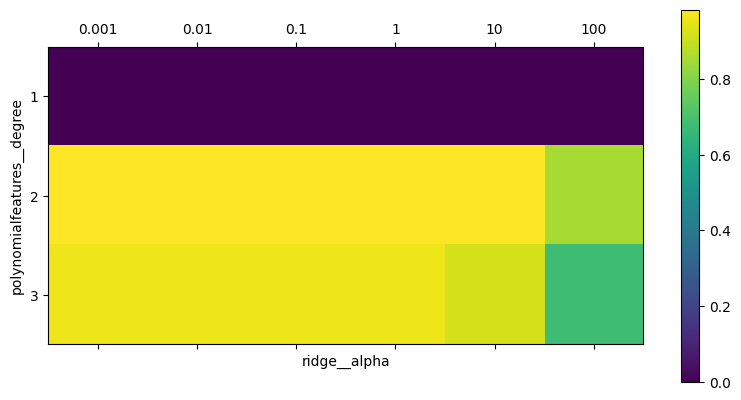

In [ ]:
plt.matshow(grid.cv_results_['mean_test_score'].reshape(3, -1),
           vmin=0, cmap="viridis")
plt.xlabel("ridge__alpha")
plt.ylabel("polynomialfeatures__degree")
plt.xticks(range(len(param_grid['ridge__alpha'])), param_grid['ridge__alpha'])
plt.yticks(range(len(param_grid['polynomialfeatures__degree'])),
           param_grid['polynomialfeatures__degree'])
plt.colorbar()

The heatmap provides a clear visualization of the model's performance, illustrating the critical role of feature selection over hyperparameter tuning. For Degree 1, the consistently negative $R^2$ scores demonstrate that a linear approach is fundamentally incapable of capturing the underlying quadratic relationships ($3x_1^2 + 2x_2 x_3$), regardless of the regularization strength. In contrast, Degree 2 achieves the most robust results with an $R^2 \approx 0.98$, as its feature space directly aligns with the true data-generating process, showing little sensitivity to the $\alpha$ parameter. While Degree 3 also performs strongly, it shows a slight decline in accuracy—particularly at lower $\alpha$ values—where the inclusion of redundant cubic terms introduces noise and increases the risk of overfitting. These findings are further substantiated by the optimal parameters identified below:

In [ ]:
print("Best parameters: {}".format(grid.best_params_))

Best parameters: {'polynomialfeatures__degree': 2, 'ridge__alpha': 1}


The grid search results identified degree=2 and $\alpha=1$ as the optimal parameters, where the selection of a quadratic degree aligns with our initial observations from the heatmap regarding the data's complexity. This configuration employs a regularization strength of $\alpha=1$, which effectively applies a balanced $\ell_2$ shrinkage; it is robust enough to mitigate overfitting across the 21 polynomial features given our 150 training samples, yet remains sufficiently flexible to avoid underfitting, ultimately yielding the following performance score:

In [ ]:
print("Test-set score: {:.2f}".format(grid.score(X_test, y_test)))

Test-set score: 0.99


The model demonstrates exceptional predictive power, achieving an $R^2$ score of 0.99 on the test set, which signifies that it captures nearly all the variance in the target variable. This high level of precision is anticipated, as the underlying data-generating process follows a second-degree polynomial, and the model has been appropriately equipped with the corresponding polynomial features. Furthermore, the minimal discrepancy between the cross-validation and test scores indicates robust generalization and an absence of overfitting; however, to further validate these results, it is worth comparing this performance against a grid search conducted without these polynomial features.

In [ ]:
param_grid = {'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100]}
pipe = make_pipeline(StandardScaler(), Ridge())
grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(X_train, y_train)
print("Score without poly features: {:.2f}".format(grid.score(X_test, y_test)))

Score without poly features: 0.04


The initial model's poor performance, indicated by an $R^2$ of merely 0.04, is unsurprising given that a purely linear approach fails to account for the quadratic and interaction terms—such as $x_1^2$ and $x_2 x_3$—inherent in our true relationship. By incorporating second-degree polynomial features, we can effectively capture these complexities and significantly improve the model's explanatory power. While integrating this preprocessing step into a GridSearchCV pipeline offers a robust strategy for simultaneous parameter tuning, we must remain mindful of the computational cost; since the total number of models scales exponentially with each additional parameter, as defined by $\text{Total models} = k_{\text{cv}} \times \prod_{i=1}^{m} |\text{values}_i|$, an overly expansive grid can quickly lead to a combinatorial explosion in training time.

## **6.1. Grid-Searching Which Model To Use**

To further optimize our workflow, we can extend the capabilities of GridSearchCV and Pipeline by treating the actual preprocessing steps as hyperparameters themselves—for instance, dynamically toggling between StandardScaler and MinMaxScaler. While this approach significantly broadens the search space and requires careful computational consideration, it allows for a more robust comparison of distinct architectural paths. For example, when evaluating a RandomForestClassifier against an SVC on the Iris dataset, we can programmatically determine whether the SVC benefits from scaling or if the data should remain raw, which is typically sufficient for tree-based models. By explicitly defining a multi-step pipeline that alternates between different scalers and classifiers, we ensure that our model selection process is both comprehensive and scientifically rigorous, even if we must remain mindful of the 'curse of dimensionality' in larger grids.

In [ ]:
pipe = Pipeline([('preprocessing', StandardScaler()), ('classifier', SVC())])

To optimize our model selection, we define a parameter_grid that evaluates both RandomForestClassifier and SVC as potential estimators. Given that these models require distinct hyperparameters and preprocessing steps, we implement a list of search grids to accommodate their specific requirements, as previously established in our discussion on non-grid search spaces. We assign each estimator to its respective pipeline stage by using the step's name as the parameter key; furthermore, in instances where certain preprocessing is redundant—such as for the Random Forest model—we can effectively bypass that stage by assigning it a value of None, ensuring a more streamlined and efficient tuning process.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

param_grid = [
    {'classifier': [SVC()], 'preprocessing': [StandardScaler(), None],
     'classifier__gamma': [0.001, 0.01, 0.1, 1, 10, 100],
     'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100]},
    {'classifier': [RandomForestClassifier(n_estimators=100)],
     'preprocessing': [None], 'classifier__max_features': [1, 2, 3]}]

Now we can instantiate and run the grid search as usual, here on the cancer dataset:

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, random_state=0)
grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best params:\n{}\n".format(grid.best_params_))
print("Best cross-validation score: {:.2f}".format(grid.best_score_))
print("Test-set score: {:.2f}".format(grid.score(X_test, y_test)))

Best params:
{'classifier': SVC(), 'classifier__C': 10, 'classifier__gamma': 0.01, 'preprocessing': StandardScaler()}

Best cross-validation score: 0.99
Test-set score: 0.98


The grid search results indicate that the SVC model, coupled with StandardScaler, outperformed the Random Forest regressor by achieving a robust 99% cross-validation accuracy and 98% test accuracy. This performance suggests that the dataset's decision boundaries are likely smooth and well-suited for a kernel SVM, provided that feature normalization is applied; indeed, the selection of StandardScaler underscores that scaling is vital for the SVM to prevent high-magnitude features from distorting the distance computations. Furthermore, the moderate regularization and broad Gaussian kernel implied by the optimal parameters reflect a well-generalized model, while the marginal 1% discrepancy between the CV and test scores confirms that the model avoids significant overfitting. Ultimately, the ability to seamlessly evaluate diverse model architectures and preprocessing steps through a single pipeline demonstrates the immense efficiency of the Pipeline abstraction in streamlining complex machine learning workflows.

### **7. Summary**

### **The Crucial Role of Algorithm Chains and Pipelines**

This chapter introduced the Pipeline class, an essential general-purpose tool designed to chain multiple processing steps together in a machine learning workflow. Real-world machine learning rarely involves an isolated model; it relies on a carefully ordered sequence of transformations and evaluations. There are several key points to keep in mind:

- Preventing Data Leakage: When doing model evaluation using cross-validation and parameter selection via grid search, the Pipeline class is absolutely essential to prevent data leakage. It ensures that transformers are only fitted on the training folds and not on the validation sets.

- Code Succinctness and Safety: Using pipelines encapsulates multiple steps into a single Python object that adheres to the standard scikit-learn interface (fit, predict, transform). It reduces the likelihood of crucial mistakes, such as forgetting to apply a transformer to the test set or applying them in the wrong sequence.

- Iterative Experimentation: Determining the perfect combination of preprocessing, feature extraction, and modeling requires trial and error. Pipelines make this "trying out" process exceptionally simple, though you should be careful not to overcomplicate your models unnecessarily.

### **Key Concepts**

- **Information Leakage** A critical error where information from the test or validation data is accidentally used to train or preprocess the model. This results in highly unrealistic and overly optimistic accuracy scores.

- **Pipeline Instantiation** Created by passing a list of (name, estimator) tuples to the Pipeline class. Alternatively, make_pipeline can be used to generate steps with automatically assigned lowercase class names.

- **Pipeline Mechanics** During fit, the pipeline iterates through all steps except the last, calling fit_transform on each, and then calls fit on the final step. During predict, it transforms the data through the initial steps before calling predict on the final estimator.

- **Grid Search Integration** The absolute best practice for hyperparameter tuning. Parameters within a pipeline are accessed in a parameter grid by appending a double underscore between the step name and the specific parameter.

- **Simultaneous Tuning** You can optimize hyperparameters for both the preprocessing steps and the machine learning model simultaneously, or even search through an entire list of different models to find the perfect algorithmic fit.